Saving Retail_Dataset_Cleaned.csv to Retail_Dataset_Cleaned (1).csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/sayalikhot21/synthetic-dataset-for-e-commerce-return-analysis
License(s): MIT
synthetic-dataset-for-e-commerce-return-analysis.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  synthetic-dataset-for-e-commerce-return-analysis.zip
replace ecommerce_returns_synthetic_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: ecommerce_returns_synthetic_data.csv  
Shape: (10000, 17)
Data cleaned
After encoding: (10000, 115)
Data split done
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5085 - loss: 0.7047 - val_accuracy: 0.5200 - val_loss: 0.6939
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5410 - loss: 0.6886 - val_accuracy: 0.5107 - val_loss: 0.6959
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5645 - loss: 0.6825 - val_accuracy: 0.5233 - val_loss: 0.6940
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5735 - loss: 0.6759 - val_accuracy: 0.5327 - val_loss: 0.6984
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5952 - loss: 0.6662 - val_accuracy: 0.5193 - val_loss: 0.7064
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6102 - loss: 0.6569 - val_accuracy: 0.5267 - val_loss: 0.7084
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6207 - loss: 0.6478 - val_accuracy: 0.5267 - val_loss: 0.7116
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6430 - loss: 0.6327 - val_accuracy: 0.5160

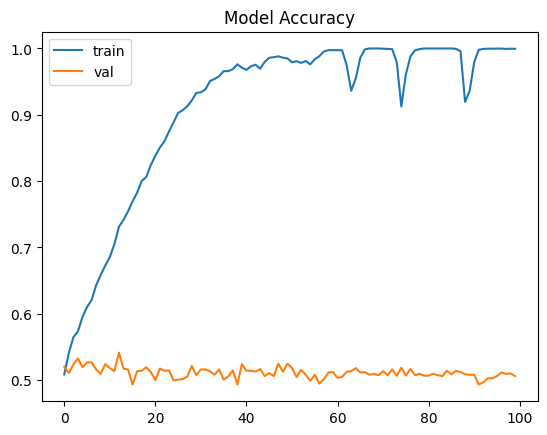

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy: 0.51

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.54      0.52      1236
           1       0.52      0.48      0.50      1264

    accuracy                           0.51      2500
   macro avg       0.51      0.51      0.51      2500
weighted avg       0.51      0.51      0.51      2500



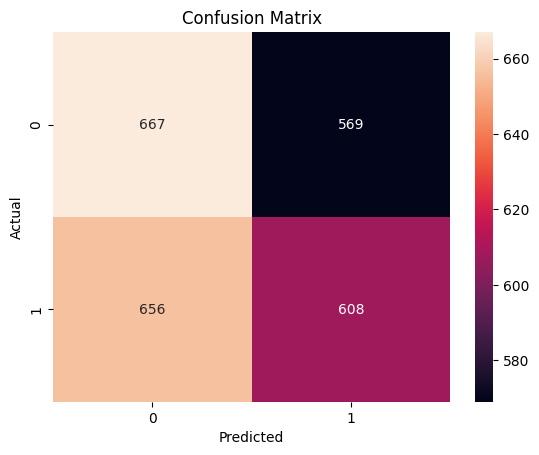

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Return Probability: [[0.0172668]]
Prediction: [[0]]
XGB Accuracy: 0.5012


In [ ]:
# Install required libraries (run in Colab)
!pip install kaggle xgboost tensorflow

# Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt
import seaborn as sns

# Upload kaggle.json manually in Colab before running this

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d sayalikhot21/synthetic-dataset-for-e-commerce-return-analysis
!unzip synthetic-dataset-for-e-commerce-return-analysis.zip

# Load CSV
df = pd.read_csv("ecommerce_returns_synthetic_data.csv")

print("Shape:", df.shape)
df.head()

# Copy dataset
clean_df = df.copy()

# Handle missing values
clean_df['clean_price'] = clean_df['Product_Price'].fillna(0)
clean_df['clean_quantity'] = clean_df['Order_Quantity'].fillna(1)

# Create target variable
clean_df['target'] = clean_df['Return_Status'].apply(
    lambda x: 1 if x == 'Returned' else 0
)

print("Data cleaned")


# Convert date
clean_df['Order_Date'] = pd.to_datetime(clean_df['Order_Date'])

# Extract features
clean_df['day'] = clean_df['Order_Date'].dt.dayofweek
clean_df['month'] = clean_df['Order_Date'].dt.month


# IMPORTANT: Do NOT use Days_to_Return (future data)

df_final = clean_df[['clean_price', 'clean_quantity',
                     'User_Age', 'Discount_Applied',
                     'Product_Category',
                     'Payment_Method',
                     'Shipping_Method',
                     'User_Location',
                     'day', 'month',
                     'target']]


# Convert categorical → numerical
df_final = pd.get_dummies(df_final, drop_first=True)

print("After encoding:", df_final.shape)


X = df_final.drop('target', axis=1)
y = df_final['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=32
)

print("Data split done")


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = Sequential([
    Dense(128, activation='leaky_relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='leaky_relu'),
    Dense(32, activation='leaky_relu'),
    Dense(1, activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)



loss, accuracy = model.evaluate(X_test, y_test)

print("Neural Network Accuracy:", accuracy)


plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Model Accuracy")
plt.show()


y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



sample = X_test[5:6]

pred = model.predict(sample)

print("Return Probability:", pred)
print("Prediction:", (pred > 0.5).astype(int))


model.save("nn_model.keras")

#OPTIONAL — XGBOOST (FOR COMPARISON ONLY)
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGB Accuracy:", accuracy_score(y_test, xgb_pred))